# The Multiple Testing Problem

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain why testing many hypotheses simultaneously inflates the false positive rate.
2. Define the **family-wise error rate (FWER)** and the **false discovery rate (FDR)**.
3. Apply the **Bonferroni** and **Šidák** corrections to control FWER.
4. Implement the **Benjamini–Hochberg** procedure from scratch to control FDR.
5. Use `statsmodels.stats.multitest.multipletests` for professional multiple testing correction.
6. Choose the appropriate correction method for a given scientific context.

## Prerequisites

- [01_hypothesis_framework.ipynb](01_hypothesis_framework.ipynb) — p-values, significance level $\alpha$, Type I errors
- [03_errors_and_power.ipynb](03_errors_and_power.ipynb) — Type I and Type II errors, statistical power

In [1]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q statsmodels")

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()

rng = np.random.default_rng(42)
print("Setup complete.")

Setup complete.


---

## 1. The Problem: Why Testing Many Hypotheses Is Dangerous

In notebook 01, we established that a single test at significance level $\alpha = 0.05$ has a 5% chance of producing a false positive when $H_0$ is true. That seems like a reasonable risk for one test. But what happens when we run **many** tests?

Consider a researcher who tests 20 different hypotheses — perhaps 20 genes for association with a disease, or 20 variants of a website button. If none of the hypotheses are actually true (all 20 null hypotheses hold), we would **still expect** $20 \times 0.05 = 1$ false positive on average.

This is not a bug in the statistical framework — it is the inevitable consequence of repeated testing. Each test has a 5% chance of a false alarm, and those chances accumulate.

Let us demonstrate this with a simulation.

In [ ]:
# Simulation: 20 hypotheses, ALL null (no real effects)
n_tests = 20
n_experiments = 10_000
alpha = 0.05
n_sample = 30  # sample size per test

false_positives_per_experiment = []

for _ in range(n_experiments):
    # Each "test" draws from N(0,1) and tests H0: mu = 0
    p_values = []
    for _ in range(n_tests):
        sample = rng.normal(0, 1, n_sample)  # H0 is TRUE
        _, p = stats.ttest_1samp(sample, 0)
        p_values.append(p)
    p_values = np.array(p_values)
    false_positives_per_experiment.append(np.sum(p_values < alpha))

false_positives_per_experiment = np.array(false_positives_per_experiment)

print(
    f"Experiments with at least one false positive: "
    f"{np.mean(false_positives_per_experiment >= 1):.1%}"
)
print(
    f"Average false positives per experiment: "
    f"{np.mean(false_positives_per_experiment):.2f}"
)
print(f"Expected (m * alpha): {n_tests * alpha:.1f}")

Experiments with at least one false positive: 63.2%
Average false positives per experiment: 0.98
Expected (m * alpha): 1.0


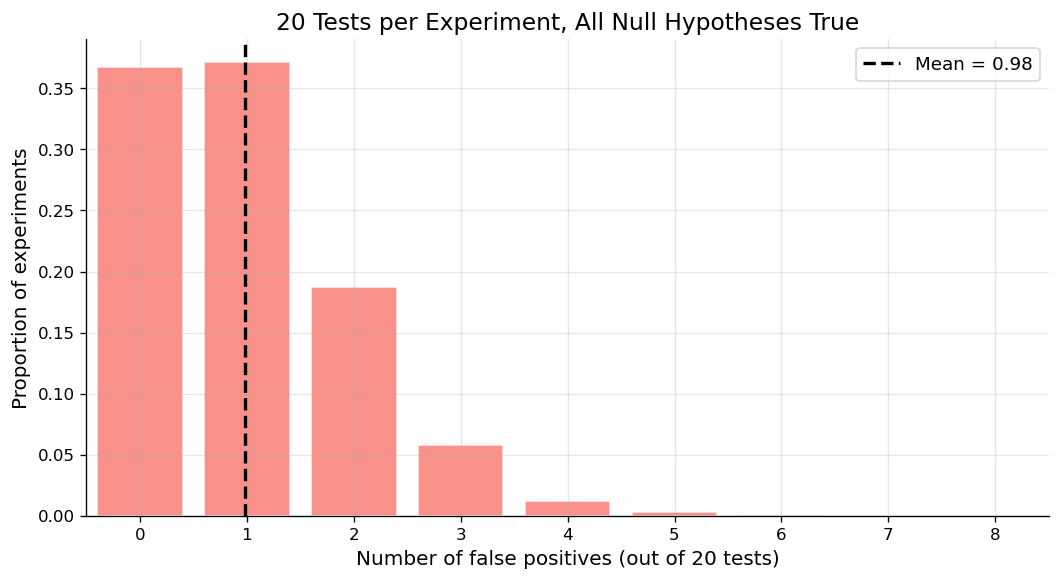

In [ ]:
# Visualise the distribution of false positives
fig, ax = plt.subplots(figsize=(9, 5))
counts = np.bincount(false_positives_per_experiment, minlength=n_tests + 1)
x = np.arange(len(counts))
ax.bar(x, counts / n_experiments, color="#F8766D", edgecolor="white", alpha=0.8)
ax.set_xlabel("Number of false positives (out of 20 tests)")
ax.set_ylabel("Proportion of experiments")
ax.set_title("20 Tests per Experiment, All Null Hypotheses True")
ax.set_xlim(-0.5, 8.5)
ax.axvline(
    np.mean(false_positives_per_experiment),
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {np.mean(false_positives_per_experiment):.2f}",
)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Even though **nothing is real** — every null hypothesis is true — roughly 64% of experiments produce at least one false positive, and on average each experiment yields about 1 spurious "discovery". This is the **multiple testing problem**.

The core issue: each individual test controls its own error rate at $\alpha$, but the **collective** error rate across all tests is much higher.

---

## 2. Family-Wise Error Rate (FWER)

To reason about the collective error rate, we need a formal definition.

> **Definition.** The **family-wise error rate (FWER)** is the probability of making **at least one** Type I error (false positive) among all the tests in a family:
>
> $$\text{FWER} = P(\text{at least one false positive})$$

For $m$ **independent** tests, each conducted at level $\alpha$, we can compute the FWER exactly. The probability of **no** false positives across all $m$ tests is $(1 - \alpha)^m$, so:

$$\text{FWER} = 1 - (1 - \alpha)^m$$

This grows rapidly with $m$:

| $m$ | FWER  |
|-----|-------|
| 1   | 0.050 |
| 5   | 0.226 |
| 10  | 0.401 |
| 20  | 0.642 |
| 50  | 0.923 |
| 100 | 0.994 |

With 100 independent tests, it is virtually **certain** that at least one will be a false positive.

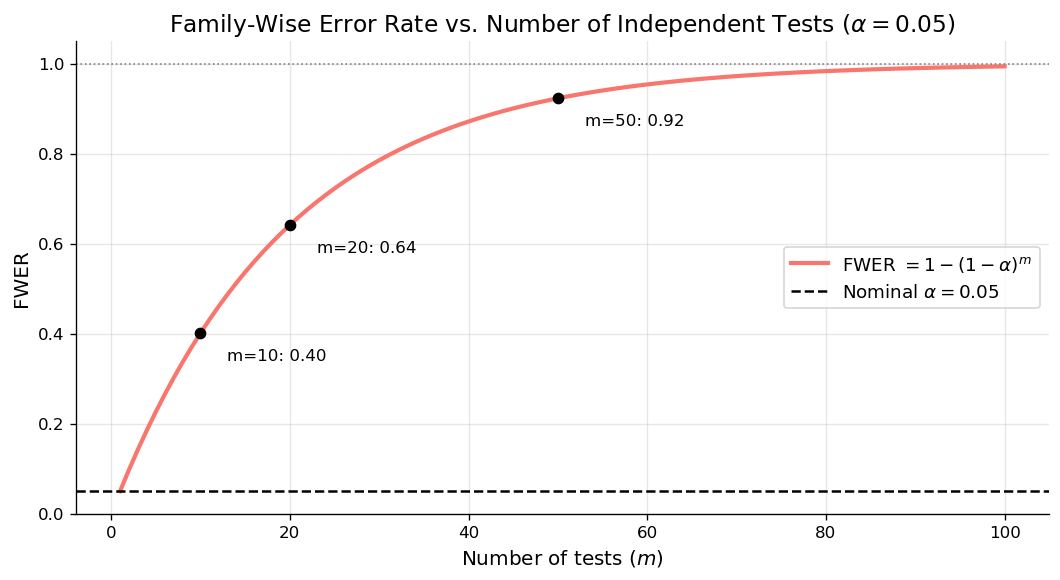

In [ ]:
# Plot FWER vs. number of tests
m_values = np.arange(1, 101)
fwer_values = 1 - (1 - alpha) ** m_values

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    m_values,
    fwer_values,
    linewidth=2.5,
    color="#F8766D",
    label=r"FWER $= 1 - (1 - \alpha)^m$",
)
ax.axhline(
    alpha,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=rf"Nominal $\alpha = {alpha}$",
)
ax.axhline(1.0, color="grey", linestyle=":", linewidth=1)

# Mark key points
for m_mark in [10, 20, 50]:
    fwer_mark = 1 - (1 - alpha) ** m_mark
    ax.plot(m_mark, fwer_mark, "ko", markersize=6)
    ax.annotate(
        f"m={m_mark}: {fwer_mark:.2f}",
        xy=(m_mark, fwer_mark),
        xytext=(m_mark + 3, fwer_mark - 0.06),
        fontsize=10,
    )

ax.set_xlabel("Number of tests ($m$)")
ax.set_ylabel("FWER")
ax.set_title(
    r"Family-Wise Error Rate vs. Number of Independent Tests ($\alpha = 0.05$)"
)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The FWER curve makes the problem viscerally clear: at $m = 20$ tests, you have a 64% chance of at least one false positive. The nominal $\alpha = 0.05$ per-test guarantee is essentially meaningless for the family as a whole.

The goal of **FWER-controlling procedures** is to adjust the per-test threshold so that the overall FWER stays at (or below) the desired $\alpha$.

---

## 3. Bonferroni Correction

The simplest and most widely used FWER correction is the **Bonferroni correction** (1936).

### The idea

If we want the overall FWER to be at most $\alpha$, and we are performing $m$ tests, we should use a stricter significance level for each individual test:

$$\alpha_{\text{Bonf}} = \frac{\alpha}{m}$$

Reject $H_{0,i}$ if $p_i \leq \alpha / m$.

### Why does this work?

By the **union bound** (Boole's inequality), for any set of events $A_1, \ldots, A_m$:

$$P\left(\bigcup_{i=1}^m A_i\right) \leq \sum_{i=1}^m P(A_i)$$

Let $A_i$ be the event "test $i$ is a false positive". If $H_{0,i}$ is true and we test at level $\alpha/m$:

$$P(A_i) = \frac{\alpha}{m}$$

Even in the worst case where all $m$ null hypotheses are true:

$$\text{FWER} = P\left(\bigcup_{i=1}^m A_i\right) \leq \sum_{i=1}^m \frac{\alpha}{m} = \alpha$$

**Key points:**
- The Bonferroni correction is valid for **any** dependence structure between the tests. It does not require independence.
- It uses an *inequality*, so it is **conservative** — the actual FWER is often less than $\alpha$, especially when tests are independent or positively correlated.
- It is very simple to apply: just divide $\alpha$ by the number of tests.

### The cost of conservatism

The Bonferroni correction trades false positives for false negatives. With $m = 100$ tests, you need $p < 0.0005$ to reject — only very strong effects survive. Many real effects may be missed, reducing **statistical power**.

In [5]:
# Bonferroni in action
m = 20
alpha_bonf = alpha / m

print(f"Number of tests: m = {m}")
print(f"Nominal alpha: {alpha}")
print(f"Bonferroni-adjusted alpha: {alpha_bonf:.4f}")
print(f"\nTo reject, a p-value must be below {alpha_bonf:.4f} instead of {alpha}")
print(f"That's {m}x more stringent.")

Number of tests: m = 20
Nominal alpha: 0.05
Bonferroni-adjusted alpha: 0.0025

To reject, a p-value must be below 0.0025 instead of 0.05
That's 20x more stringent.


---

## 4. Šidák Correction

The **Šidák correction** (1967) is a slightly less conservative alternative to Bonferroni, valid when the tests are **independent**.

### Derivation

For $m$ independent tests, we want:

$$\text{FWER} = 1 - (1 - \alpha_{\text{adj}})^m = \alpha$$

Solving for $\alpha_{\text{adj}}$:

$$(1 - \alpha_{\text{adj}})^m = 1 - \alpha$$

$$\alpha_{\text{adj}} = 1 - (1 - \alpha)^{1/m}$$

### Comparison with Bonferroni

The Šidák threshold is always **slightly larger** (less conservative) than the Bonferroni threshold $\alpha/m$. The difference is small for moderate $m$ but becomes noticeable for very large $m$.

In [ ]:
# Compare Bonferroni and Sidak thresholds
m_vals = np.array([2, 5, 10, 20, 50, 100, 500, 1000])

bonf_thresh = alpha / m_vals
sidak_thresh = 1 - (1 - alpha) ** (1 / m_vals)

print(f"{'m':>6}  {'Bonferroni':>12}  {'Sidak':>12}  {'Ratio (S/B)':>12}")
print("-" * 48)
for m_v, b, s in zip(m_vals, bonf_thresh, sidak_thresh):
    print(f"{m_v:>6d}  {b:>12.6f}  {s:>12.6f}  {s / b:>12.4f}")

     m    Bonferroni         Sidak   Ratio (S/B)
------------------------------------------------
     2      0.025000      0.025321        1.0128
     5      0.010000      0.010206        1.0206
    10      0.005000      0.005116        1.0232
    20      0.002500      0.002561        1.0246
    50      0.001000      0.001025        1.0253
   100      0.000500      0.000513        1.0256
   500      0.000100      0.000103        1.0258
  1000      0.000050      0.000051        1.0258


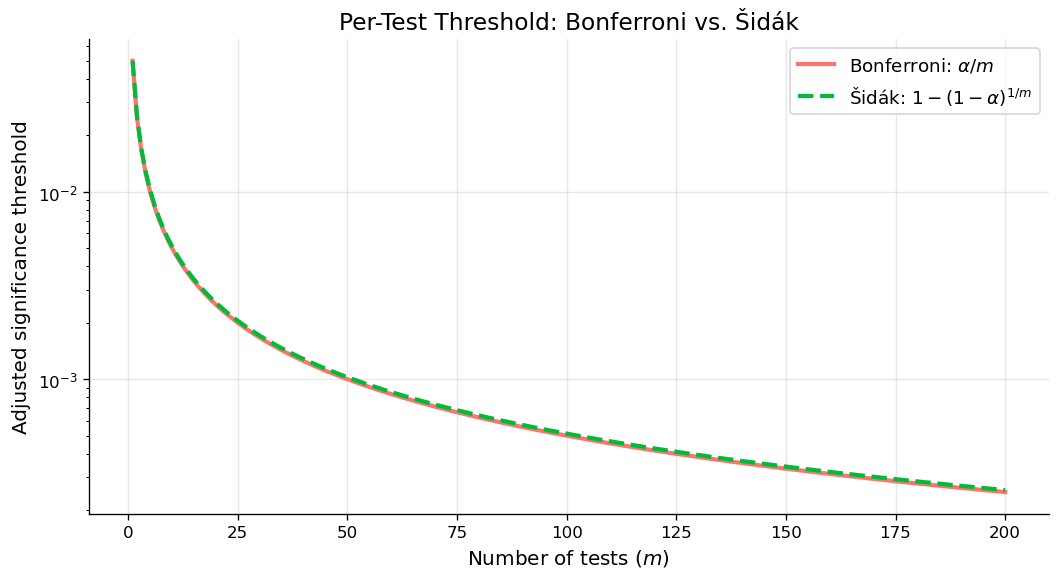

In [ ]:
# Visualise the two thresholds
m_range = np.arange(1, 201)
bonf_line = alpha / m_range
sidak_line = 1 - (1 - alpha) ** (1 / m_range)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    m_range, bonf_line, linewidth=2.5, label="Bonferroni: $\\alpha/m$", color="#F8766D"
)
ax.plot(
    m_range,
    sidak_line,
    linewidth=2.5,
    linestyle="--",
    label=r"Šidák: $1 - (1-\alpha)^{1/m}$",
    color="#00BA38",
)
ax.set_xlabel("Number of tests ($m$)")
ax.set_ylabel("Adjusted significance threshold")
ax.set_title("Per-Test Threshold: Bonferroni vs. Šidák")
ax.set_yscale("log")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The Šidák line sits just above the Bonferroni line — a slightly less stringent threshold, giving marginally more power. In practice, the difference is small and both are often reported together.

**Caveat:** Šidák requires independence. When tests are correlated (as in many real applications), Bonferroni is the safer choice because it makes no assumptions about dependence.

---

## 5. The False Discovery Rate (FDR)

FWER control is very strict: it guards against **any** false positive at all. In many modern applications — genomics, brain imaging, large-scale A/B testing — we perform thousands or millions of tests. Bonferroni at $m = 20{,}000$ means $\alpha_{\text{adj}} = 2.5 \times 10^{-6}$, which obliterates our power to detect real effects.

**Do we really need to guarantee zero false positives?** Often the answer is no. If we test 20,000 genes and find 200 significant, we might tolerate a few false positives among those 200 — as long as the *proportion* of false discoveries is controlled.

This motivates a less conservative error metric.

> **Definition.** The **false discovery rate (FDR)** is the expected proportion of false positives among all rejected hypotheses:
>
> $$\text{FDR} = E\left[\frac{V}{R}\right]$$
>
> where $V$ is the number of false positives (false discoveries) and $R$ is the total number of rejections. By convention, $V/R = 0$ when $R = 0$.

### FWER vs. FDR

| Property   | FWER                          | FDR                                               |
|------------|-------------------------------|---------------------------------------------------|
| Controls   | P(any false positive)         | E(proportion of false positives among rejections) |
| Strictness | Very conservative             | Less conservative                                 |
| Power      | Low when $m$ is large         | Higher — finds more true positives                |
| Use case   | Safety-critical (drug trials) | Exploratory (genomics, screening)                 |

If FWER is like saying "I want zero innocent people convicted", FDR is like saying "I want at most 5% of convictions to be wrongful." The latter is more practical when processing many cases.

---

## 6. The Benjamini–Hochberg (BH) Procedure

Benjamini and Hochberg (1995) introduced a simple, elegant procedure that controls the FDR at level $q$ (commonly $q = 0.05$).

### Algorithm

Given $m$ p-values $p_1, p_2, \ldots, p_m$:

1. **Sort** the p-values in ascending order: $p_{(1)} \leq p_{(2)} \leq \cdots \leq p_{(m)}$.
2. **Find the largest $k$** such that $p_{(k)} \leq \frac{k}{m} \cdot q$.
3. **Reject** all hypotheses with $p_{(i)} \leq p_{(k)}$ (i.e., reject the $k$ smallest p-values).

Equivalently, we can compute **adjusted p-values** (BH q-values): starting from the largest p-value and working backwards, each adjusted p-value is:

$$\tilde{p}_{(i)} = \min\left(\frac{m}{i} \cdot p_{(i)},\; 1\right)$$

enforcing monotonicity: $\tilde{p}_{(i)} = \min\left(\tilde{p}_{(i)},\; \tilde{p}_{(i+1)}\right)$.

### Intuition

The BH procedure draws a line $y = \frac{k}{m} q$ through p-value space. The smallest p-values that fall below this line are rejected. The line gets steeper for higher-ranked p-values, reflecting the idea that if many p-values are small, we can afford to be less strict (there are likely many real effects).

### Worked example

Suppose we have $m = 10$ tests with the following p-values, and we want to control FDR at $q = 0.05$:

In [ ]:
# Worked example: BH procedure step by step
p_raw = np.array([0.005, 0.009, 0.012, 0.03, 0.04, 0.11, 0.25, 0.42, 0.65, 0.91])
m_ex = len(p_raw)
q = 0.05

# Step 1: sort (already sorted)
ranks = np.arange(1, m_ex + 1)
bh_threshold = ranks / m_ex * q

print(f"BH Procedure with m = {m_ex} tests, q = {q}")
print(f"{'Rank k':>7}  {'p_(k)':>8}  {'k/m * q':>8}  {'p <= threshold?':>16}")
print("-" * 43)

largest_k = 0
for k, (p, thresh) in enumerate(zip(p_raw, bh_threshold), 1):
    reject = p <= thresh
    if reject:
        largest_k = k
    marker = "  <-- reject" if reject else ""
    print(
        f"{k:>7d}  {p:>8.4f}  {thresh:>8.4f}  {'Yes' if reject else 'No':>16}{marker}"
    )

print(f"\nLargest k where p_(k) <= k/m * q: k = {largest_k}")
print(f"Reject the {largest_k} hypotheses with the smallest p-values.")

BH Procedure with m = 10 tests, q = 0.05
 Rank k     p_(k)   k/m * q   p <= threshold?
-------------------------------------------
      1    0.0050    0.0050               Yes  <-- reject
      2    0.0090    0.0100               Yes  <-- reject
      3    0.0120    0.0150               Yes  <-- reject
      4    0.0300    0.0200                No
      5    0.0400    0.0250                No
      6    0.1100    0.0300                No
      7    0.2500    0.0350                No
      8    0.4200    0.0400                No
      9    0.6500    0.0450                No
     10    0.9100    0.0500                No

Largest k where p_(k) <= k/m * q: k = 3
Reject the 3 hypotheses with the smallest p-values.


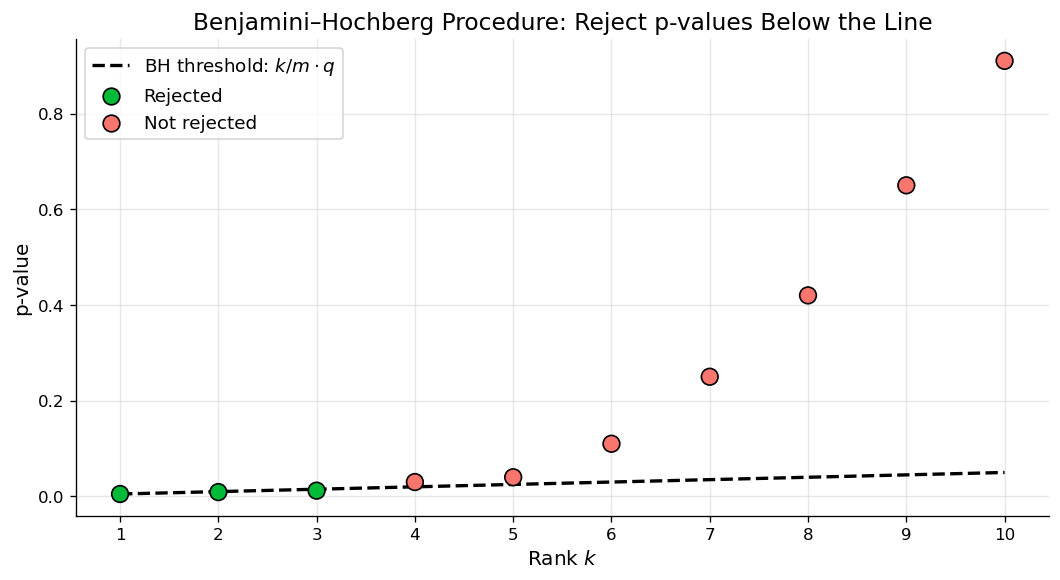

In [9]:
# Visualise the BH procedure
fig, ax = plt.subplots(figsize=(9, 5))

# BH line
ax.plot(ranks, bh_threshold, "k--", linewidth=2, label=f"BH threshold: $k/m \\cdot q$")

# p-values
colors = ["#00BA38" if i <= largest_k else "#F8766D" for i in ranks]
ax.scatter(ranks, p_raw, c=colors, s=100, zorder=5, edgecolors="black")

for i, (k, p) in enumerate(zip(ranks, p_raw)):
    label = "Rejected" if i == 0 else ("Not rejected" if i == largest_k else None)
    if i == 0:
        ax.scatter([], [], c="#00BA38", s=100, edgecolors="black", label="Rejected")
    if i == largest_k:
        ax.scatter([], [], c="#F8766D", s=100, edgecolors="black", label="Not rejected")

ax.set_xlabel("Rank $k$")
ax.set_ylabel("p-value")
ax.set_title("Benjamini–Hochberg Procedure: Reject p-values Below the Line")
ax.legend(fontsize=11)
ax.set_xticks(ranks)
plt.tight_layout()
plt.show()

The green dots (below the BH line) are rejected; the red dots (above) are not. Notice that the BH procedure rejected the first 3 p-values. Even though $p_{(4)} = 0.03$ is below $\alpha = 0.05$, it does **not** pass the BH threshold because $0.03 > 4/10 \times 0.05 = 0.02$.

### From-scratch implementation

In [10]:
def benjamini_hochberg(p_values, q=0.05):
    """
    Benjamini-Hochberg procedure for FDR control.

    Parameters
    ----------
    p_values : array-like
        Raw p-values from m hypothesis tests.
    q : float
        Desired FDR level (default 0.05).

    Returns
    -------
    rejected : ndarray of bool
        True for hypotheses that are rejected.
    adjusted_p : ndarray
        BH-adjusted p-values (q-values).
    """
    p = np.asarray(p_values, dtype=float)
    m = len(p)

    # Sort p-values and track original order
    sorted_idx = np.argsort(p)
    sorted_p = p[sorted_idx]
    ranks = np.arange(1, m + 1)

    # Compute adjusted p-values (working backwards for monotonicity)
    adjusted = np.minimum(sorted_p * m / ranks, 1.0)
    # Enforce monotonicity: adjusted[i] <= adjusted[i+1]
    for i in range(m - 2, -1, -1):
        adjusted[i] = min(adjusted[i], adjusted[i + 1])

    # Map back to original order
    adjusted_original = np.empty(m)
    adjusted_original[sorted_idx] = adjusted

    rejected = adjusted_original <= q
    return rejected, adjusted_original


# Test on our worked example
rejected, adj_p = benjamini_hochberg(p_raw, q=0.05)

print(f"{'p-value':>10}  {'Adjusted p':>12}  {'Rejected':>10}")
print("-" * 36)
for p, ap, r in zip(p_raw, adj_p, rejected):
    print(f"{p:>10.4f}  {ap:>12.4f}  {'Yes' if r else 'No':>10}")

   p-value    Adjusted p    Rejected
------------------------------------
    0.0050        0.0400         Yes
    0.0090        0.0400         Yes
    0.0120        0.0400         Yes
    0.0300        0.0750          No
    0.0400        0.0800          No
    0.1100        0.1833          No
    0.2500        0.3571          No
    0.4200        0.5250          No
    0.6500        0.7222          No
    0.9100        0.9100          No


---

## 7. Professional Tool: `statsmodels.stats.multitest`

In practice, you should use a well-tested library implementation. The `statsmodels` package provides `multipletests`, which supports Bonferroni, Šidák, Benjamini–Hochberg, and many other methods.

In [11]:
from statsmodels.stats.multitest import multipletests

# Apply several correction methods to the same p-values
methods = [
    ("bonferroni", "Bonferroni"),
    ("sidak", "Šidák"),
    ("fdr_bh", "Benjamini–Hochberg (FDR)"),
]

print(f"Raw p-values: {p_raw}\n")

for method_code, method_name in methods:
    reject, pvals_adj, _, _ = multipletests(p_raw, alpha=0.05, method=method_code)
    n_reject = np.sum(reject)
    print(f"{method_name}:")
    print(f"  Adjusted p-values: [{', '.join(f'{p:.4f}' for p in pvals_adj)}]")
    print(f"  Rejections: {n_reject} (indices: {np.where(reject)[0].tolist()})")
    print()

Raw p-values: [0.005 0.009 0.012 0.03  0.04  0.11  0.25  0.42  0.65  0.91 ]

Bonferroni:
  Adjusted p-values: [0.0500, 0.0900, 0.1200, 0.3000, 0.4000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
  Rejections: 1 (indices: [0])

Šidák:
  Adjusted p-values: [0.0489, 0.0864, 0.1137, 0.2626, 0.3352, 0.6882, 0.9437, 0.9957, 1.0000, 1.0000]
  Rejections: 1 (indices: [0])

Benjamini–Hochberg (FDR):
  Adjusted p-values: [0.0400, 0.0400, 0.0400, 0.0750, 0.0800, 0.1833, 0.3571, 0.5250, 0.7222, 0.9100]
  Rejections: 3 (indices: [0, 1, 2])



In [12]:
# Verify our from-scratch BH matches statsmodels
reject_sm, pvals_sm, _, _ = multipletests(p_raw, alpha=0.05, method="fdr_bh")
reject_ours, pvals_ours = benjamini_hochberg(p_raw, q=0.05)

print("Our implementation matches statsmodels?")
print(f"  Rejections match: {np.array_equal(reject_sm, reject_ours)}")
print(f"  Adjusted p-values match: {np.allclose(pvals_sm, pvals_ours)}")

Our implementation matches statsmodels?
  Rejections match: True
  Adjusted p-values match: True


The `multipletests` function returns:
1. `reject` — boolean array of rejection decisions
2. `pvals_corrected` — adjusted p-values
3. `alphacSidak` — Šidák-corrected alpha (for FWER methods)
4. `alphacBonf` — Bonferroni-corrected alpha

Other available methods include `'holm'` (step-down Bonferroni, uniformly more powerful than Bonferroni), `'fdr_by'` (Benjamini–Yekutieli, FDR under arbitrary dependence), and more. See the [statsmodels documentation](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html).

---

## 8. Simulation: Comparing Methods Head-to-Head

Let us now run a large-scale simulation to compare all three correction methods. We will perform 1,000 experiments, each with 20 tests where **all null hypotheses are true** (the global null). This lets us measure the actual false positive rate for each method.

In [ ]:
# Large-scale simulation: all null hypotheses true
n_sim = 1_000
m_sim = 20
n_per_test = 30

results = {
    "Uncorrected": {"any_fp": 0, "total_fp": 0},
    "Bonferroni": {"any_fp": 0, "total_fp": 0},
    "Šidák": {"any_fp": 0, "total_fp": 0},
    "BH (FDR)": {"any_fp": 0, "total_fp": 0},
}

for _ in range(n_sim):
    # Generate p-values: all null true
    p_vals = np.array(
        [stats.ttest_1samp(rng.normal(0, 1, n_per_test), 0)[1] for _ in range(m_sim)]
    )

    # Uncorrected
    uncorr_reject = p_vals < alpha
    results["Uncorrected"]["any_fp"] += np.any(uncorr_reject)
    results["Uncorrected"]["total_fp"] += np.sum(uncorr_reject)

    # Bonferroni
    bonf_reject, _, _, _ = multipletests(p_vals, alpha=alpha, method="bonferroni")
    results["Bonferroni"]["any_fp"] += np.any(bonf_reject)
    results["Bonferroni"]["total_fp"] += np.sum(bonf_reject)

    # Sidak
    sidak_reject, _, _, _ = multipletests(p_vals, alpha=alpha, method="sidak")
    results["Šidák"]["any_fp"] += np.any(sidak_reject)
    results["Šidák"]["total_fp"] += np.sum(sidak_reject)

    # BH
    bh_reject, _, _, _ = multipletests(p_vals, alpha=alpha, method="fdr_bh")
    results["BH (FDR)"]["any_fp"] += np.any(bh_reject)
    results["BH (FDR)"]["total_fp"] += np.sum(bh_reject)

print(f"Simulation: {n_sim} experiments, {m_sim} tests each, ALL null hypotheses true")
print(f"{'Method':>15}  {'FWER (any FP)':>14}  {'Avg FP per exp':>15}")
print("-" * 50)
for method, res in results.items():
    fwer = res["any_fp"] / n_sim
    avg_fp = res["total_fp"] / n_sim
    print(f"{method:>15}  {fwer:>14.3f}  {avg_fp:>15.3f}")

Simulation: 1000 experiments, 20 tests each, ALL null hypotheses true
         Method   FWER (any FP)   Avg FP per exp
--------------------------------------------------
    Uncorrected           0.644            1.011
     Bonferroni           0.049            0.050
          Šidák           0.050            0.051
       BH (FDR)           0.050            0.058


Key observations:

- **Uncorrected**: ~64% of experiments have at least one false positive — far above $\alpha = 0.05$.
- **Bonferroni and Šidák**: FWER is controlled at approximately $\alpha = 0.05$, as guaranteed.
- **BH (FDR)**: The FWER is higher than $\alpha$ — but that is by design. BH controls the *false discovery proportion*, not the probability of any false positive. Under the global null, FDR and FWER coincide, so BH still controls at $\alpha$.

Now let us run a more realistic scenario where **some hypotheses are true**.

In [ ]:
# More realistic simulation: some effects are real
n_sim2 = 1_000
m_sim2 = 20
n_true_effects = 5  # 5 out of 20 have a real effect
effect_size = 0.8  # Cohen's d

power_results = {
    "Uncorrected": {"fp": 0, "tp": 0, "fn": 0, "tn": 0},
    "Bonferroni": {"fp": 0, "tp": 0, "fn": 0, "tn": 0},
    "BH (FDR)": {"fp": 0, "tp": 0, "fn": 0, "tn": 0},
}

for _ in range(n_sim2):
    p_vals = []
    truth = []  # True = H1 is true (real effect)

    for j in range(m_sim2):
        if j < n_true_effects:
            # Real effect
            sample = rng.normal(effect_size, 1, n_per_test)
            truth.append(True)
        else:
            # Null is true
            sample = rng.normal(0, 1, n_per_test)
            truth.append(False)
        _, p = stats.ttest_1samp(sample, 0)
        p_vals.append(p)

    p_vals = np.array(p_vals)
    truth = np.array(truth)

    for method_name, method_code in [
        ("Uncorrected", None),
        ("Bonferroni", "bonferroni"),
        ("BH (FDR)", "fdr_bh"),
    ]:
        if method_code is None:
            reject = p_vals < alpha
        else:
            reject, _, _, _ = multipletests(p_vals, alpha=alpha, method=method_code)

        power_results[method_name]["tp"] += np.sum(reject & truth)
        power_results[method_name]["fp"] += np.sum(reject & ~truth)
        power_results[method_name]["fn"] += np.sum(~reject & truth)
        power_results[method_name]["tn"] += np.sum(~reject & ~truth)

print(f"Simulation: {n_sim2} experiments, {m_sim2} tests each")
print(
    f"  {n_true_effects} real effects (d = {effect_size}), {m_sim2 - n_true_effects} nulls\n"
)
print(
    f"{'Method':>15}  {'Power':>7}  {'FPR':>7}  {'FDR':>7}  {'Total TP':>9}  {'Total FP':>9}"
)
print("-" * 60)
for method, r in power_results.items():
    power = r["tp"] / (r["tp"] + r["fn"]) if (r["tp"] + r["fn"]) > 0 else 0
    fpr = r["fp"] / (r["fp"] + r["tn"]) if (r["fp"] + r["tn"]) > 0 else 0
    fdr = r["fp"] / (r["fp"] + r["tp"]) if (r["fp"] + r["tp"]) > 0 else 0
    print(
        f"{method:>15}  {power:>7.3f}  {fpr:>7.3f}  {fdr:>7.3f}  {r['tp']:>9d}  {r['fp']:>9d}"
    )

Simulation: 1000 experiments, 20 tests each
  5 real effects (d = 0.8), 15 nulls

         Method    Power      FPR      FDR   Total TP   Total FP
------------------------------------------------------------
    Uncorrected    0.990    0.048    0.128       4950        724
     Bonferroni    0.843    0.002    0.008       4214         33
       BH (FDR)    0.946    0.013    0.039       4730        190


This simulation reveals the **trade-off** clearly:

- **Uncorrected** testing has high power (catches most real effects) but an unacceptable false discovery rate.
- **Bonferroni** has very few false positives but **lower power** — it misses some real effects.
- **BH (FDR)** strikes a balance: it catches more real effects than Bonferroni while keeping the proportion of false discoveries under control.

This is why BH has become the default correction method in many fields: it provides a principled way to be less conservative than FWER control without abandoning error control entirely.

---

## 9. Real-World Context

Multiple testing corrections are not just a theoretical concern. They arise constantly in modern science and industry.

### Genomics

A genome-wide association study (GWAS) tests hundreds of thousands of genetic variants for association with a disease. With $m = 500{,}000$ tests, the Bonferroni threshold is $\alpha / m = 10^{-7}$, which is the standard "genome-wide significance" threshold of $5 \times 10^{-8}$. This is extremely stringent, and many real associations with small effect sizes are missed. The field increasingly uses FDR control for discovery, followed by replication in independent cohorts.

### Brain imaging (fMRI)

A brain scan produces ~100,000 voxels, each tested for activation. Bonferroni at this scale ($\alpha / 100{,}000 = 5 \times 10^{-7}$) is too conservative. The field uses:
- **Random Field Theory** to account for spatial correlation between voxels.
- **FDR control** as a less conservative alternative.
- **Cluster-level inference** — testing whether *clusters* of adjacent voxels are activated, rather than individual voxels.

A famous cautionary tale: Bennett et al. (2009) scanned a **dead Atlantic salmon** with fMRI and found "significant" brain activation when using uncorrected thresholds. With proper multiple testing correction, the spurious activations disappeared. This paper ("Neural Correlates of Interspecies Perspective Taking in the Post-Mortem Atlantic Salmon") won an Ig Nobel Prize and became a landmark argument for correction.

### A/B testing in tech

A tech company might run hundreds of A/B tests simultaneously (different button colours, layouts, copy text). Without correction, 5% of tests will show "significant" improvements that are actually noise. Companies like Netflix, Airbnb, and Google use FDR control or sequential testing methods to manage this.

### Clinical trials

When a drug trial tests multiple endpoints (e.g., does the drug reduce pain *and* improve mobility *and* reduce inflammation?), regulators (FDA, EMA) require FWER control — typically Bonferroni or the Holm procedure. The stakes are too high for FDR: approving a drug based on a false positive could harm patients.

### Summary: when to use which method

| Scenario                      | Recommended method             | Rationale                                         |
|-------------------------------|--------------------------------|---------------------------------------------------|
| Clinical trial, few endpoints | **Bonferroni / Holm**          | Safety-critical; FWER control required            |
| Regulatory submission         | **Bonferroni / Holm**          | Regulators require FWER control                   |
| Genomics discovery            | **Benjamini–Hochberg**         | Thousands of tests; need power, tolerate some FP  |
| Brain imaging                 | **FDR or Random Field Theory** | Very many tests with spatial correlation          |
| A/B testing (many variants)   | **Benjamini–Hochberg**         | Exploratory; prioritise finding real improvements |
| Confirmatory (few tests)      | **Bonferroni**                 | Simple, conservative, universally accepted        |

---

## Exercises

**Exercise 4.1 (FWER calculation).** A researcher conducts $m = 15$ independent tests at $\alpha = 0.10$.

(a) What is the FWER if no correction is applied?  
(b) What per-test threshold does the Bonferroni correction prescribe?  
(c) What per-test threshold does the Šidák correction prescribe?  
(d) Verify your answers by simulation (10,000 experiments, all nulls true).

**Exercise 4.2 (BH by hand).** Given the p-values $\{0.001, 0.015, 0.030, 0.048, 0.055, 0.10, 0.22, 0.35, 0.60, 0.85\}$ and FDR level $q = 0.10$:

(a) Apply the Benjamini–Hochberg procedure by hand (show the table).  
(b) Which hypotheses are rejected?  
(c) How many more rejections does BH give compared to Bonferroni at $\alpha = 0.10$?

**Exercise 4.3 (Power vs. conservatism).** Simulate 1,000 experiments with $m = 50$ tests. In each experiment, 10 tests have a true effect ($\mu = 0.5$, $\sigma = 1$, $n = 25$) and 40 are null. For each method (uncorrected, Bonferroni, BH at $q = 0.05$), compute:

(a) The empirical power (proportion of true effects detected).  
(b) The empirical FDR (proportion of rejections that are false positives).  
(c) Plot power vs. FDR for the three methods. Which method would you recommend?

**Exercise 4.4 (Dependent tests).** The Bonferroni correction is valid under any dependence. The BH procedure is valid under independence or positive regression dependence (PRDS). Simulate $m = 20$ tests where all test statistics are drawn from a multivariate normal with pairwise correlation $\rho = 0.5$. Does Bonferroni still control FWER? Does BH still control FDR? Compare to the independent case.

**Exercise 4.5 (The Holm procedure).** The Holm step-down procedure (1979) is uniformly more powerful than Bonferroni while still controlling FWER. Look up the algorithm and implement it from scratch. Apply it to the p-values from Exercise 4.2 and compare to Bonferroni. Verify against `multipletests(method='holm')`.

---

## Key Takeaways

1. **Testing many hypotheses inflates false positives.** With $m$ tests at $\alpha = 0.05$, the probability of at least one false positive is $1 - (1 - \alpha)^m$, which approaches 1 rapidly.

2. **FWER controls the probability of *any* false positive.** Bonferroni ($\alpha/m$) and Šidák ($1 - (1-\alpha)^{1/m}$) are simple FWER-controlling methods. Bonferroni is valid under any dependence; Šidák requires independence.

3. **FWER methods are conservative.** They sacrifice power (ability to detect real effects) to avoid any false positives. This trade-off is acceptable when the cost of a false positive is very high (e.g., drug approval).

4. **FDR controls the *proportion* of false positives among rejections.** This is a less strict criterion, appropriate for exploratory research where some false positives are tolerable.

5. **The Benjamini–Hochberg procedure** is the standard FDR-controlling method. It is more powerful than Bonferroni and has become the default in genomics, neuroimaging, and large-scale A/B testing.

6. **Choose the correction based on context:** FWER for confirmatory/safety-critical settings, FDR for exploratory/high-throughput settings.

7. **Always report whether and how you corrected for multiple comparisons.** Failing to correct — or failing to disclose the number of tests performed — is a common source of irreproducible results.

**Next:** [05_roc_curves.ipynb](05_roc_curves.ipynb) — ROC curves, sensitivity vs. specificity, and the AUC as a measure of classification performance.